# Task 6: House Price Prediction

## Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

## Load the Dataset

In [3]:
houses = pd.read_csv('House Price Prediction Dataset.csv')

## Clean DataSet

In [4]:
# Clean and Inspect the Dataset
print("\nMissing Values:\n", houses.isnull().sum())
# Handle missing values: Impute with mean for numeric columns only
numeric_columns = houses.select_dtypes(include=['float64', 'int64']).columns
houses[numeric_columns] = houses[numeric_columns].fillna(houses[numeric_columns].mean())
# Summary statistics
print("\nDescriptive Statistics:\n", houses.describe())

# Convert categorical columns to numeric using get_dummies
categorical_columns = houses.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    houses = pd.get_dummies(houses, columns=categorical_columns, drop_first=True)




Missing Values:
 Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Descriptive Statistics:
                 Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.

## Perform EDA

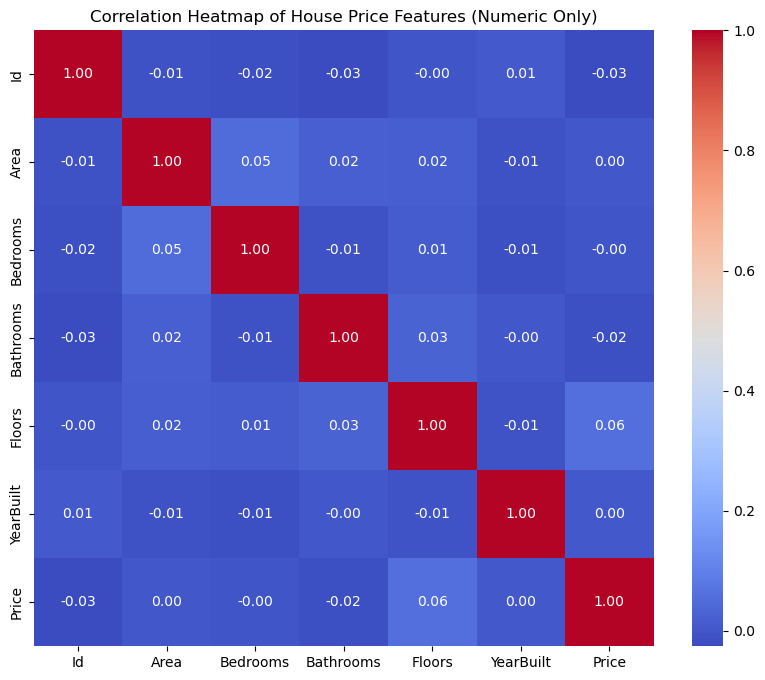

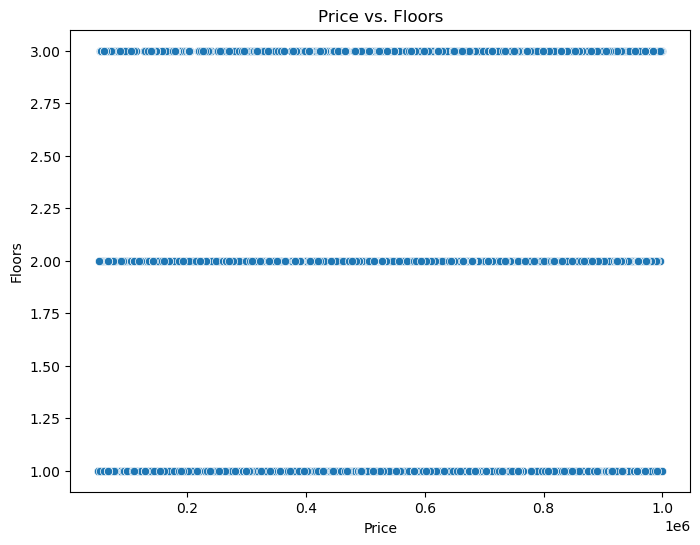

In [6]:
# Exploratory Data Analysis (EDA)
# Correlation heatmap (only for numeric columns)
plt.figure(figsize=(10, 8))
sns.heatmap(houses[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of House Price Features (Numeric Only)')
plt.savefig('correlation_heatmap.png')
plt.show()  # Display the plot
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=houses, x='Price', y='Floors')  
plt.title('Price vs. Floors')
plt.xlabel('Price')  # Update label based on feature
plt.ylabel('Floors')
plt.savefig('price_vs_floors.png')
plt.show()  # Display the plot

## Train Model

In [9]:
# Train the Model
# Split data into features and target
X = houses.drop('Price', axis=1)
y = houses['Price']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Evaluate Model

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



Mean Absolute Error (MAE): 242867.44926338628
Root Mean Squared Error (RMSE): 279785.21069002635


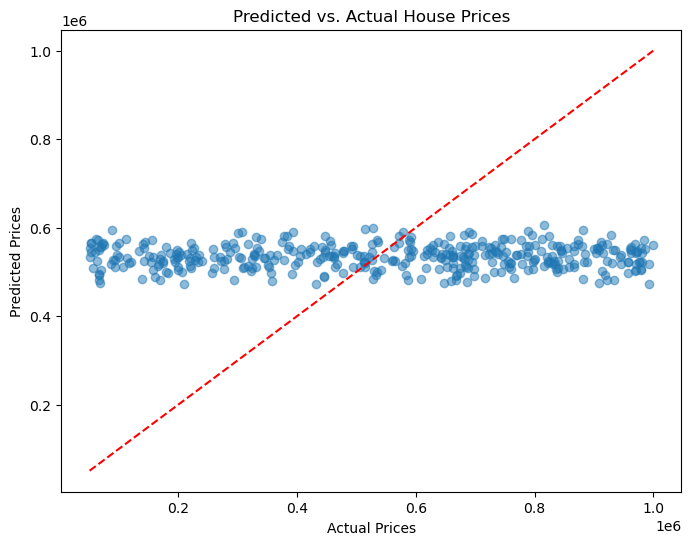

In [10]:
#Evaluate the Model
# Predictions
y_pred = model.predict(X_test)
# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print("\nMean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
# Visualize predicted vs. actual prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs. Actual House Prices')
plt.savefig('predicted_vs_actual.png')
plt.show()  # Display the plot

## Feature Importance

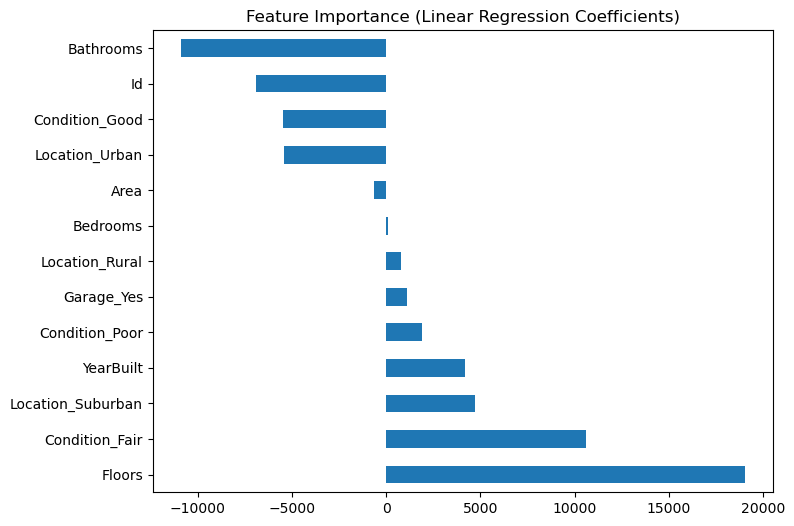

In [11]:

# Feature Importance
# Linear Regression coefficients
feature_importance = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.savefig('feature_importance.png')
plt.show()  # Display the plot